**Problema de despacho como un juego de suma cero**

alejandro.garces@utp.edu.co

Agosto de 2026

In [1]:
## Instalar paquetes
paquetes = ["Plots", "LinearAlgebra", "JuMP", "Ipopt", "ForwardDiff"]
using Pkg
for paquete in paquetes
    if !haskey(Pkg.project().dependencies, paquete)
        @info "Instalando $paquete..."
        Pkg.add(paquete)
    end
end
for paquete in paquetes
	 @eval using $(Symbol(paquete))
end

In [2]:
# construccion de una instancia aleatoria del problema
n = 10
xopt = rand(n)
xopt = xopt./sum(xopt)
b = rand(n)
lopt = 100
a = sqrt.((-b.*xopt.+lopt)./0.5);

In [3]:
Despacho = Model(Ipopt.Optimizer)
@variable(Despacho, x[1:n])
@objective(Despacho,Min,sum(0.5*a.*x.^2 .+ b.*x))
@constraint(Despacho, balance, sum(x) == 1)
optimize!(Despacho)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       10
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality c

In [4]:
#Optimo primal
xopt = round.(value.(x), digits=3)

10-element Vector{Float64}:
 0.134
 0.085
 0.143
 0.087
 0.095
 0.092
 0.074
 0.091
 0.078
 0.12

In [5]:
λopt = -shadow_price.(balance)

2.0429445720765753

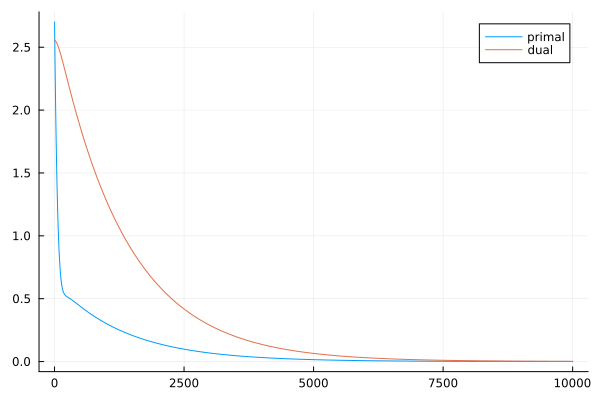

In [6]:
# modelo como un juego de suma cero con lagrangeano normal
# Jugador 1: busca minimizar L mediante el metodo del gradiente sobre las variables x
# Jugador 2: busca maximizar L mediante el metodo del gradiente sobre las variables λ
paso_primal = 0.001
paso_dual = 0.001
nt = 10000
x_paso = randn(n)
λ_paso = -rand()
L(x,λ) = sum(sum(0.5*a.*x.^2 .+ b.*x) - λ*(sum(x)-1))
gr_error_primal = ones(nt)
gr_error_dual = ones(nt)
gr_payoff = zeros(nt)
for k = 1:nt
    f(x) = L(x,λ_paso)
    df = ForwardDiff.gradient(f,x_paso)
    x_paso -= df*paso_primal
    g(λ) = L(x_paso,λ)
    dg = ForwardDiff.derivative(g,λ_paso)
    λ_paso += dg*paso_dual
    gr_error_primal[k] = norm(x_paso-xopt)
    gr_error_dual[k] = abs(λ_paso-λopt)
    gr_payoff[k] = L(x_paso,λ_paso)
end
plot(gr_error_primal,label="primal")
plot!(gr_error_dual, label="dual")

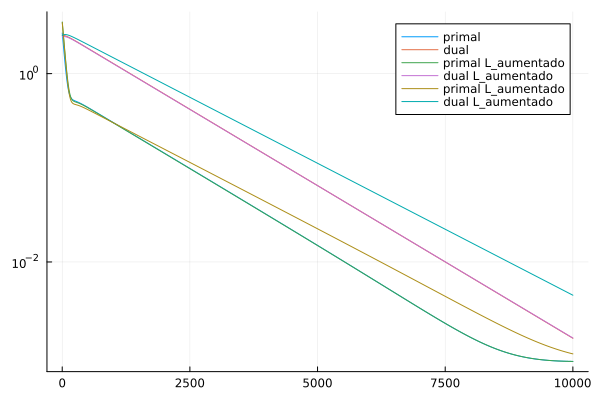

In [8]:
# modelo como un juego de suma cero con lagrangeano aumentado
# Jugador 1: busca minimizar L mediante el metodo del gradiente sobre las variables x
# Jugador 2: busca maximizar L mediante el metodo del gradiente sobre las variables λ
paso_primal = 0.001
paso_dual = 0.001
nt = 10000
x_paso = randn(n)
λ_paso = -rand()
L(x,λ) = sum(sum(0.5*a.*x.^2 .+ b.*x) - λ*(sum(x)-1) + 0.1*(sum(x)-1)^2 )
gr_error_primal = ones(nt)
gr_error_dual = ones(nt)
gr_payoff = zeros(nt)
for k = 1:nt
    f(x) = L(x,λ_paso)
    df = ForwardDiff.gradient(f,x_paso)
    x_paso -= df*paso_primal
    g(λ) = L(x_paso,λ)
    dg = ForwardDiff.derivative(g,λ_paso)
    λ_paso += dg*paso_dual
    gr_error_primal[k] = norm(x_paso-xopt)
    gr_error_dual[k] = abs(λ_paso-λopt)
    gr_payoff[k] = L(x_paso,λ_paso)
end
plot!(gr_error_primal,label="primal L_aumentado",yaxis = :log10)
plot!(gr_error_dual, label="dual L_aumentado",yaxis = :log10)